In [1]:
import xscen as xs
import xarray as xr
import figanos.matplotlib as fg
fg.utils.set_mpl_style('ouranos')
import xclim as xc
import glob
import pandas as pd
import numpy as np
import matplotlib
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
from matplotlib import gridspec
import copy
import sys
from matplotlib.patches import Rectangle


pd.set_option('display.max_rows', None)

from xscen import CONFIG
xs.load_config("../config/ARCHES/config_Scaling.yml",  "../config/ARCHES/paths_Scaling.yml", reset=True)
cat_sim = xs.DataCatalog(CONFIG['extraction']['simulation']['search_data_catalogs']['data_catalogs'][0])

# CRCM5 mask
sfltf=cat_sim.search(source='CRCM5-SN', experiment='historical', variable='sftlf', driving_model='CanESM5').to_dataset(xarray_open_kwargs={'engine':'h5netcdf'})
mask = xs.regrid.create_mask(
                    sfltf,
                    **CONFIG["extraction"]["simulation"]["create_mask"],
                )
variables=['tasmax', 'tasmin','pr']
fe={ 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}

map_proj=ccrs.LambertConformal()
#map_proj=ccrs.RotatedPole(pole_longitude=87.59703130293302,pole_latitude=31.758312454493154,) # proj of casr

style_colors = matplotlib.rcParams["axes.prop_cycle"].by_key()["color"]
key_colors= {'CaSR':style_colors[0], 'raw':style_colors[1],'ESPO':style_colors[2],'Scaling':style_colors[3],}



if not Path(CONFIG['figures']).exists():
    Path(CONFIG['figures']).mkdir(parents=True, exist_ok=True)


/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# Create catalogue

In [3]:
# patts = [
#     "/staging/{type}/{processing_level}/{bias_adjust_project}_{version}_{bias_adjust_reference}/{mip_era}/{activity}/{domain}/{institution}/{source}/{experiment}/{member}/{frequency}/{variable}/{?:_}_{DATES}.zarr.zip",
#     "/staging/{type}/{processing_level}/{bias_adjust_project}_{version}_{bias_adjust_reference}/{mip_era}/{activity}/{domain}/{institution}/{source}/{driving_model}/{driving_member}/{experiment}/{member}/{frequency}/{variable}/{?:_}_{DATES}.zarr.zip"
# ]
# df = xs.catutils.parse_directory(directories=[CONFIG['scaling'], CONFIG['espo']],
#                                  patterns=patts,
#                                  )

# display(df)
# cat = xs.ProjectCatalog.create(
#     f'{CONFIG['arches']}/cat_ARCHES.json',
#     project={'title': 'tmp_cat','id': 'tmp'},
#     overwrite=True
# )
# cat.update(df)
#cat = xs.ProjectCatalog(f'{CONFIG['arches']}/cat_ARCHES.json')
cat = xs.ProjectCatalog(f'/project/ctb-frigon/julavoie/ARCHES/scaling/cat_ARCHES.json')
display(cat.df)

,id,type,processing_level,bias_adjust_institution,bias_adjust_project,bias_adjust_reference,mip_era,activity,driving_model,driving_member,...,member,xrfreq,frequency,variable,domain,date_start,date_end,version,format,path
0,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r4i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r4i1p1f1,...,r1,D,day,"(tasmax,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
1,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r4i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r4i1p1f1,...,r1,D,day,"(dtr,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
2,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r4i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r4i1p1f1,...,r1,D,day,"(pr,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
3,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r4i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r4i1p1f1,...,r1,D,day,"(tasmin,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
4,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r5i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r5i1p1f1,...,r1,D,day,"(tasmin,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
5,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r5i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r5i1p1f1,...,r1,D,day,"(dtr,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
6,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r5i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r5i1p1f1,...,r1,D,day,"(tasmax,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
7,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r5i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r5i1p1f1,...,r1,D,day,"(pr,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
8,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r2i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r2i1p1f1,...,r1,D,day,"(tasmin,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...
9,Scaling_CaSR_CMIP6_CORDEX_MPI-ESM1-2-LR_r2i1p1...,simulation,biasadjusted,NaN,Scaling,CaSR,CMIP6,CORDEX,MPI-ESM1-2-LR,r2i1p1f1,...,r1,D,day,"(dtr,)",NAM,1951-01-01,2100-12-31 23:00:00,v20,zarr,/project/ctb-frigon/julavoie/ARCHES/scaling/st...


# DQM vs Scaling

## Spatial pattern


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo

2026-07-15 09:32:42 INFO     xscen.utils     Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}


INFO:xscen.utils:Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}


2026-07-15 09:32:44 INFO     xscen.utils     Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}


...

INFO:xscen.utils:Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


2026-07-15 09:33:26 INFO     xscen.utils     Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
INFO:xscen.utils:Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


2026-07-15 09:33:44 INFO     xscen.utils     Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}


INFO:xscen.utils:Converting units: {'tasmax': 'degC', 'tasmin': 'degC', 'pr': 'mm/day'}
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


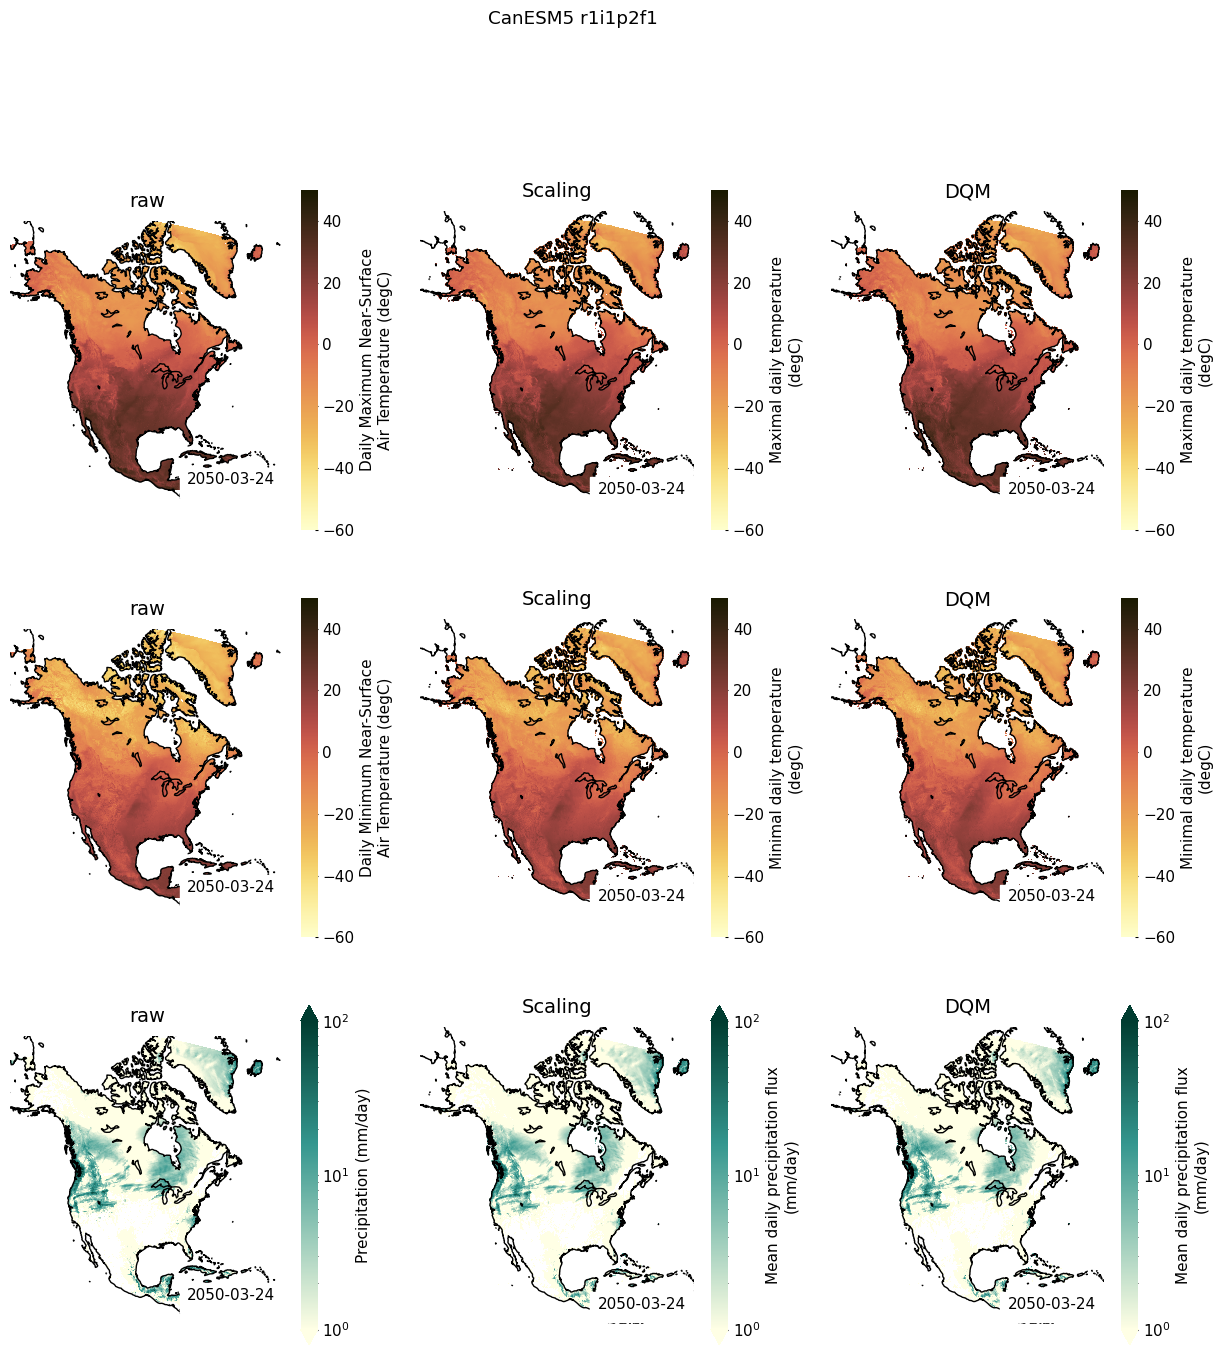

In [16]:
pw= {'tasmax': {'vmax':50,'vmin':-60},
    'tasmin': {'vmax':50,'vmin':-60},
    'pr': dict(norm=LogNorm(vmin=1, vmax=100))
    }
t='2050-03-24'
raw_dict=cat_sim.search(source='CRCM5-SN',driving_model='CanESM5', xrfreq='D',variable=variables, processing_level='raw', experiment='ssp370').to_dataset_dict(xarray_open_kwargs={'engine':'h5netcdf'})
for sim_id, ds_raw in raw_dict.items():
    dm=ds_raw.attrs['cat:driving_model']
    mem=ds_raw.attrs['cat:driving_member']
    ds_raw=xs.utils.clean_up(ds_raw, variables_and_units={'tasmax':'degC', 'tasmin':'degC', 'pr':'mm/day'})
    ds_raw=ds_raw.where(mask)
 

    
    fig, axs= plt.subplots(3,3, subplot_kw={'projection': map_proj}, figsize=(15,15))
    fig.suptitle(f"{dm} {mem}", y=1)
    for i,var in enumerate(variables):
            
        fg.gridmap(ds_raw[var].sel(time=t),show_time=True, ax=axs[i,0], features=fe,
                   plot_kw=pw[var].copy()
                  )
        axs[i,0].set_title('raw')
                               
        for j,m in enumerate(['Scaling', 'ESPO'],1):
            ds=cat.search(bias_adjust_project=m, driving_model=dm,driving_member=mem, source='CRCM5-SN', experiment='ssp370', variable=var).to_dataset()
            ds=xs.utils.clean_up(ds, variables_and_units={'tasmax':'degC', 'tasmin':'degC', 'pr':'mm/day'})
            fg.gridmap(ds.sel(time=t),show_time=True, ax=axs[i,j], features=fe,
                       plot_kw=pw[var].copy()
                      )
            axs[i,j].set_title(m.replace("ESPO","DQM"))
    plt.savefig(f"{CONFIG['figures']}/spatial_{dm}_{mem}.png",bbox_inches='tight')


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


...

/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo

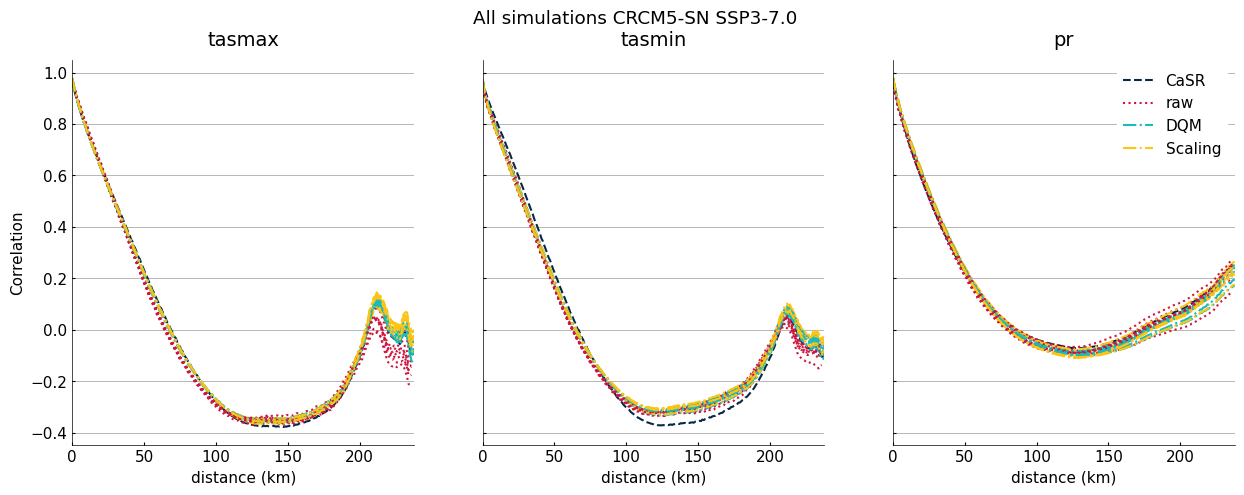

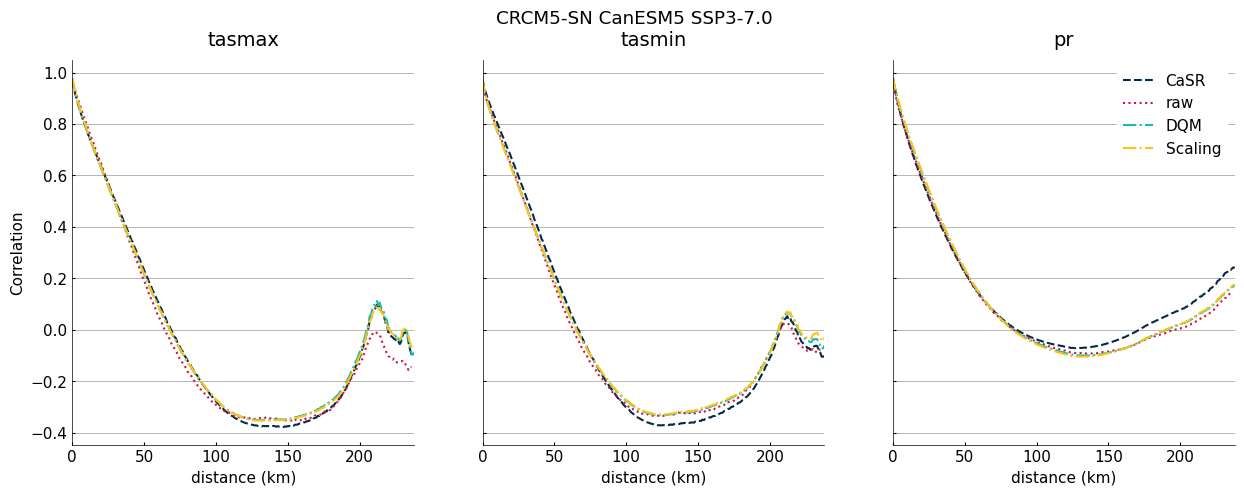

In [20]:
#spatial correlogram
# created by running post-workflow-analysis/correlogram.py
fig, axs = plt.subplots(1,3, figsize=(15,5), sharex=True,sharey=True)
fig.suptitle('All simulations CRCM5-SN SSP3-7.0')
axs[0].set_ylabel('Correlation')

for i,var in enumerate(variables):
    axs[i].set_title(var)
    sc_ref= xr.open_zarr(f"{CONFIG['arches']}/correlogram/CaSR_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False).spatial_correlogram
    
    axs[i].plot(sc_ref, label='CaSR', linestyle='--', color=key_colors['CaSR'])
    axs[i].set_xlabel('distance (km)')

    adj_dict=cat.search(source='CRCM5-SN', experiment='ssp370', bias_adjust_project='ESPO').to_dataset_dict()
    for sim_id, ds in adj_dict.items():
        dm=ds.attrs['cat:driving_model']
        mem=ds.attrs['cat:driving_member']
        
        sc_espo= xr.open_zarr(f"{CONFIG['arches']}/correlogram/ESPO_{dm}_{mem}_CRCM5-SN_ssp370_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False)
        sc_scaling= xr.open_zarr(f"{CONFIG['arches']}/correlogram/Scaling_{dm}_{mem}_CRCM5-SN_ssp370_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False)

        sc_ext = xr.open_zarr(f"{CONFIG['arches']}/correlogram/raw_{dm}_{mem}_CRCM5-SN_ssp370_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False)

        axs[i].plot(sc_ext.spatial_correlogram, label=f'raw' , linestyle=':', color=key_colors['raw'])
        axs[i].plot(sc_espo.spatial_correlogram, label='DQM',color=key_colors['ESPO'], linestyle='-.')
        axs[i].plot(sc_scaling.spatial_correlogram, label='Scaling',color=key_colors['Scaling'], linestyle='-.')

    

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

fig, axs = plt.subplots(1,3, figsize=(15,5), sharex=True,sharey=True)
fig.suptitle('CRCM5-SN CanESM5 SSP3-7.0')
axs[0].set_ylabel('Correlation')

for i,var in enumerate(variables):
    axs[i].set_title(var)
    sc_ref= xr.open_zarr(f"{CONFIG['arches']}/correlogram/CaSR_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False).spatial_correlogram
    
    axs[i].plot(sc_ref, label='CaSR', linestyle='--', color=key_colors['CaSR'])
    axs[i].set_xlabel('distance (km)')

    adj_dict=cat.search(source='CRCM5-SN', driving_model='CanESM5', experiment='ssp370', bias_adjust_project='ESPO').to_dataset_dict()
    for sim_id, ds in adj_dict.items():
        dm=ds.attrs['cat:driving_model']
        mem=ds.attrs['cat:driving_member']
        
        sc_espo= xr.open_zarr(f"{CONFIG['arches']}/correlogram/ESPO_{dm}_{mem}_CRCM5-SN_ssp370_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False)
        sc_scaling= xr.open_zarr(f"{CONFIG['arches']}/correlogram/Scaling_{dm}_{mem}_CRCM5-SN_ssp370_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False)

        sc_ext = xr.open_zarr(f"{CONFIG['arches']}/correlogram/raw_{dm}_{mem}_CRCM5-SN_ssp370_atlas_correlogram-{var}.zarr.zip", decode_timedelta=False)

        axs[i].plot(sc_ext.spatial_correlogram, label=f'raw' , linestyle=':', color=key_colors['raw'])
        axs[i].plot(sc_espo.spatial_correlogram, label='DQM',color=key_colors['ESPO'], linestyle='-.')
        axs[i].plot(sc_scaling.spatial_correlogram, label='Scaling',color=key_colors['Scaling'], linestyle='-.')

    

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.savefig(f"{CONFIG['figures']}/correlogram_CanESM5_atlas.pdf",bbox_inches='tight')
                     


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo

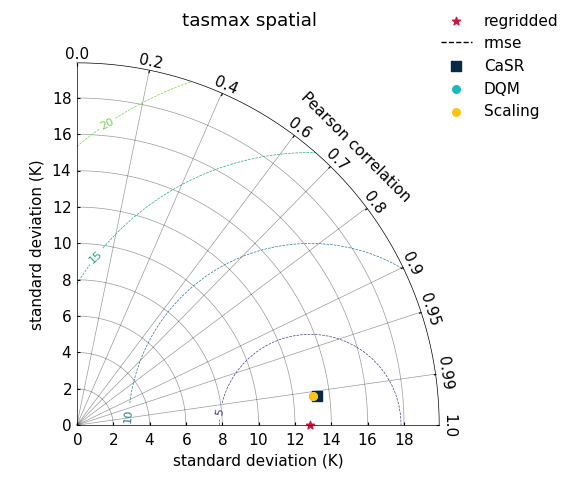

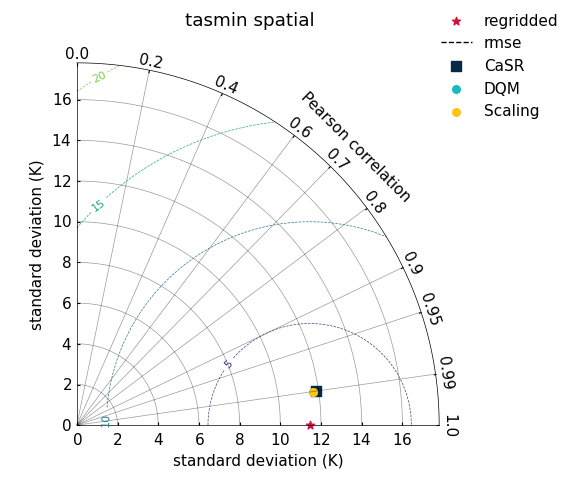

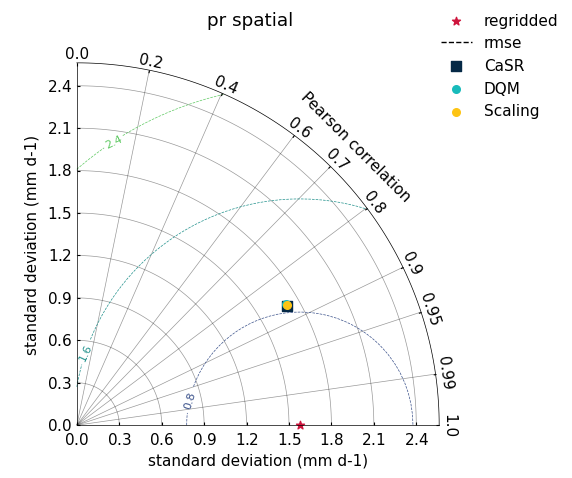

In [4]:
# spatial taylor diag
# created by running post-workflow-analysis/taylordiag.py
s=30
for i,var in enumerate(variables):


    d={}   
        
    adj_dict=cat.search(source='CRCM5-SN', experiment='ssp370', bias_adjust_project='ESPO', driving_model='CanESM5').to_dataset_dict()
    for sim_id, ds in adj_dict.items():
        dm=ds.attrs['cat:driving_model']
        mem=ds.attrs['cat:driving_member']

        out_ref = xr.open_zarr(f"{CONFIG['arches']}/taylordiag/CaSR_{dm}_{mem}_CRCM5-SN_ssp370_taylordiag-spatial-{var}.zarr.zip")
        d['CaSR']=out_ref.taylordiagram
            
        for baj in ['ESPO','Scaling']:
            out = xr.open_zarr(f"{CONFIG['arches']}/taylordiag/{baj}_{dm}_{mem}_CRCM5-SN_ssp370_taylordiag-spatial-{var}.zarr.zip")
            d[baj.replace('ESPO','DQM')]=out.taylordiagram


            
        
        fig, floating_ax, legend=fg.taylordiagram(
            d,
            plot_kw={"reference": {'color': key_colors['raw'],"marker": "*"},
                    'CaSR': {'color': key_colors['CaSR'],"marker": "s", "s":50},
                    'DQM':{'color': key_colors['ESPO'], "s":s},
                     'Scaling':{'color': key_colors['Scaling'], "s":s},
                    },
        )
        legend.get_texts()[0].set_text('regridded')
        #fig.suptitle(f"{dm} {mem} {var} spatial")
        fig.suptitle(f"{var} spatial")
        plt.savefig(f"{CONFIG['figures']}/taylordiagram-spatial_{dm}_{var}.pdf",bbox_inches='tight')

## temporal


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


...

/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo

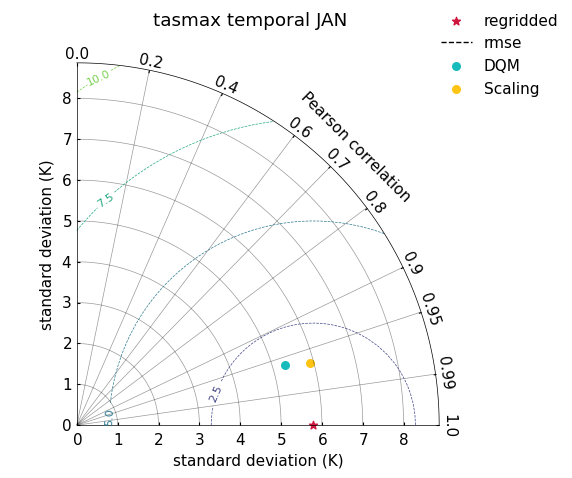

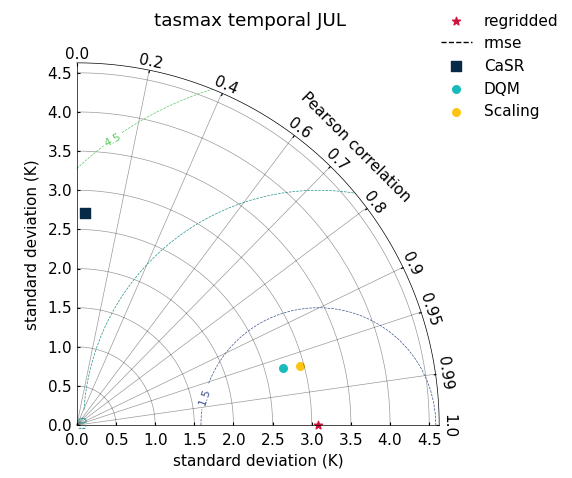

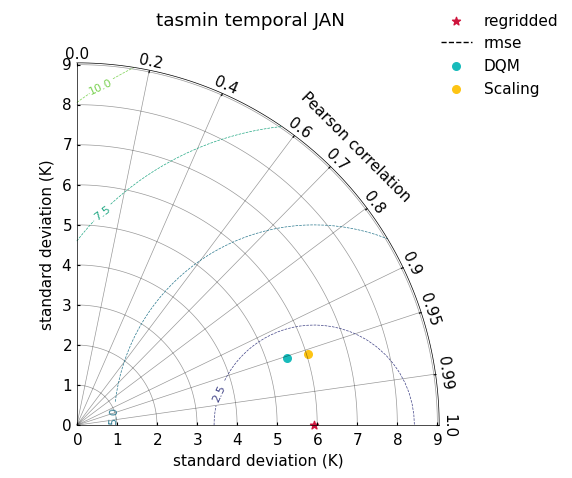

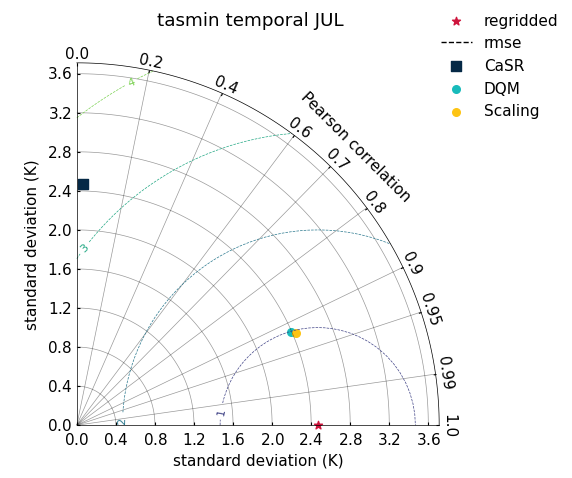

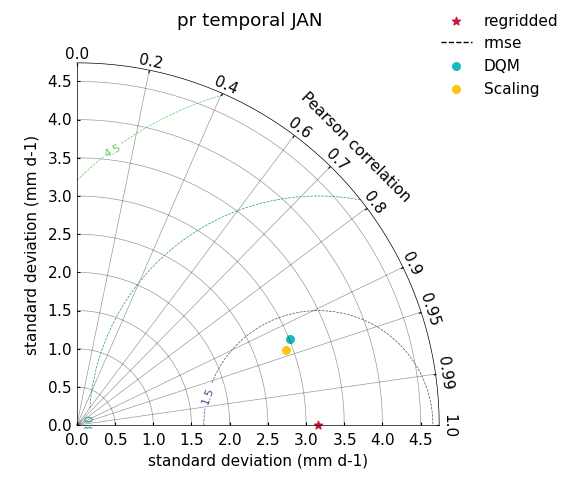

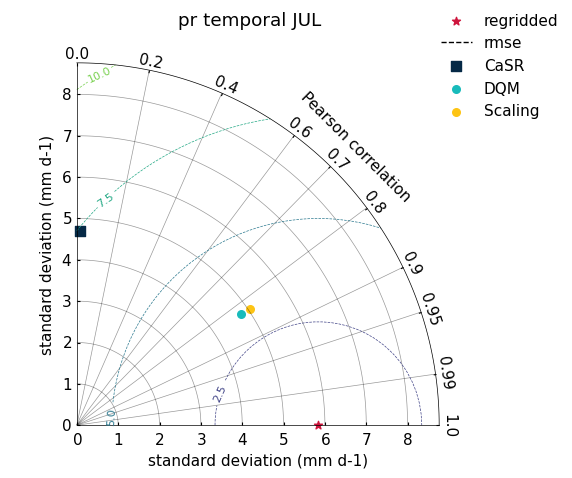

In [6]:
# temporaltaylor diag
# created by running post-workflow-analysis/taylordiag.py
s=30
for i,var in enumerate(variables):
    for month in ['JAN','JUL']:

    
        d={}   
            
        adj_dict=cat.search(source='CRCM5-SN', experiment='ssp370', bias_adjust_project='ESPO', driving_model='CanESM5').to_dataset_dict()
        for sim_id, ds in adj_dict.items():
            dm=ds.attrs['cat:driving_model']
            mem=ds.attrs['cat:driving_member']
    
            out_ref = xr.open_zarr(f"{CONFIG['arches']}/taylordiag/CaSR_{dm}_{mem}_CRCM5-SN_ssp370_taylordiag-temporal{month}-{var}.zarr.zip")
            d['CaSR']=out_ref.taylordiagram
                
            for baj in ['ESPO','Scaling']:
                out = xr.open_zarr(f"{CONFIG['arches']}/taylordiag/{baj}_{dm}_{mem}_CRCM5-SN_ssp370_taylordiag-temporal{month}-{var}.zarr.zip")
                d[baj.replace('ESPO','DQM')]=out.taylordiagram
    
    
                
            
            fig, floating_ax, legend=fg.taylordiagram(
                d,
                plot_kw={"reference": {'color': key_colors['raw'],"marker": "*"},
                        'CaSR': {'color': key_colors['CaSR'],"marker": "s", "s":50},
                        'DQM':{'color': key_colors['ESPO'], "s":s},
                         'Scaling':{'color': key_colors['Scaling'], "s":s},
                        },
            )
            legend.get_texts()[0].set_text('regridded')
            #fig.suptitle(f"{dm} {mem} {var} spatial")
            fig.suptitle(f"{var} temporal {month}")
            plt.savefig(f"{CONFIG['figures']}/taylordiagram-temporal{month}_{dm}_{var}.pdf",bbox_inches='tight')

## VALUE

In [77]:
def _rmse(sim, ref):
    return np.sqrt(np.nanmean((sim - ref) ** 2, axis=-1))

def maps2(prop_ref, prop_sim, prop_scen1, prop_scen2, meas_sim_prop, meas_scen1_prop, meas_scen2_prop):
    "Load properties and measures and plot them."
    
    
    # #TODO: tmp until run with new xscen and fix xsdba
    # prop_ref.attrs['grid_mapping']='crs'
    prop_sim.attrs['grid_mapping']='rotated_pole'
    prop_scen1.attrs['grid_mapping']='rotated_pole'
    prop_scen2.attrs['grid_mapping']='rotated_pole'

    # meas_sim_prop.attrs['grid_mapping']='crs'
    meas_scen1_prop.attrs['grid_mapping']='rotated_pole'
    meas_scen2_prop.attrs['grid_mapping']='rotated_pole'

    


    prop_long_name=prop_sim.attrs['long_name'] 
    meas_long_name=meas_sim_prop.attrs['long_name'] 
    # change units
    if prop_ref.attrs['units']=='kg m-2 s-1':
        prop_ref = xc.core.units.convert_units_to(prop_ref, 'mm d-1', context='hydro')
        prop_sim = xc.core.units.convert_units_to(prop_sim, 'mm d-1', context='hydro')
        prop_scen1 = xc.core.units.convert_units_to(prop_scen1, 'mm d-1', context='hydro')
        prop_scen2 = xc.core.units.convert_units_to(prop_scen2, 'mm d-1', context='hydro')
        meas_sim_prop = xc.core.units.convert_units_to(meas_sim_prop, 'mm d-1', context='hydro')
        meas_scen1_prop = xc.core.units.convert_units_to(meas_scen1_prop, 'mm d-1', context='hydro')
        meas_scen2_prop = xc.core.units.convert_units_to(meas_scen2_prop, 'mm d-1', context='hydro')
        
    if prop_ref.attrs['units']=='K':
        prop_ref = xc.core.units.convert_units_to(prop_ref, 'degC')
        prop_sim = xc.core.units.convert_units_to(prop_sim, 'degC')
        prop_scen1 = xc.core.units.convert_units_to(prop_scen, 'degC')
        prop_scen2 = xc.core.units.convert_units_to(prop_scen, 'degC')
        
    #set colormap
    maxi_prop = max(prop_ref.max().values, prop_scen1.max().values, prop_scen2.max().values, prop_sim.max().values)
    mini_prop = min(prop_ref.min().values, prop_scen1.min().values, prop_scen2.min().values, prop_sim.min().values)
    maxi_meas = float(max(abs(meas_scen1_prop).where(~np.isinf(meas_scen1_prop)).max().values,
                          abs(meas_scen2_prop).where(~np.isinf(meas_scen2_prop)).max().values,
                          abs(meas_sim_prop).where(~np.isinf(meas_sim_prop)).max().values))

    #plot
    fig = plt.figure(figsize=(15, 10))
    map_proj = fg.utils.get_rotpole(prop_sim)
    gs = gridspec.GridSpec(3, 3)
    ax0= fig.add_subplot(gs[1,0],projection=map_proj)
    ax1= fig.add_subplot(gs[0,1],projection=fg.utils.get_rotpole(prop_sim))
    ax2= fig.add_subplot(gs[0,2],projection=map_proj)
    ax3= fig.add_subplot(gs[1,1],projection=fg.utils.get_rotpole(prop_scen1))
    ax4= fig.add_subplot(gs[1,2],projection=fg.utils.get_rotpole(meas_scen1_prop))
    ax5= fig.add_subplot(gs[2,1],projection=fg.utils.get_rotpole(prop_scen2))
    ax6= fig.add_subplot(gs[2,2],projection=fg.utils.get_rotpole(meas_scen2_prop))

    plot_kw_prop=dict(add_colorbar=False, vmin=mini_prop,vmax=maxi_prop)
    plot_kw_meas=dict(add_colorbar=False, vmin=-maxi_meas,vmax=maxi_meas)
    features={ 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}
    #plot
    # deep copy until bug is fix TODO
    #TODO: choose cmap by end until figanos >5.0.0 is out and can use divergent
    #var_group=str(fg.utils.get_var_group(f"{sys.executable[:-10]}/lib/python3.13/site-packages/figanos/data/ipcc_colors/variable_groups.json",
    var_group=str(fg.utils.get_var_group(unique_str=f"{sys.executable[:-10]}/lib/python3.11/site-packages/figanos/data/ipcc_colors/variable_groups.json",                            
        da=meas_sim_prop))
    cmap=f"{var_group}_div"
    
    fg.gridmap(prop_ref, ax=ax0, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))
    fg.gridmap(prop_sim, ax=ax1, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))
    fg.gridmap(prop_scen1, ax=ax3, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))
    fg.gridmap(prop_scen2, ax=ax5, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))

    fg.gridmap(meas_sim_prop, ax=ax2, plot_kw=copy.deepcopy(plot_kw_meas),cmap=cmap, features=copy.deepcopy(features))
    fg.gridmap(meas_scen1_prop, ax=ax4, plot_kw=copy.deepcopy(plot_kw_meas),cmap=cmap, features=copy.deepcopy(features))
    fg.gridmap(meas_scen2_prop, ax=ax6, plot_kw=copy.deepcopy(plot_kw_meas),cmap=cmap, features=copy.deepcopy(features))

    #prop colorbar
    fig.subplots_adjust(bottom=0.1)
    cbar_ax = fig.add_axes([0.15, -0.1, 0.45, 0.03])
    cb1=fig.colorbar(ax0.get_children()[0], cax=cbar_ax,orientation='horizontal')
    cb1.set_label(label=f"{prop_long_name} ({prop_sim.attrs['units']})",size=13)
    cb1.ax.tick_params(axis='x', direction='out')
    cb1.outline.set_visible(False)
    
    #meas colorbar
    cbar_ax = fig.add_axes([0.68, -0.1, 0.25, 0.03])
    cb2=fig.colorbar(ax2.get_children()[0], cax=cbar_ax,orientation='horizontal')
    cb2.set_label(label=f"{meas_long_name} ({meas_sim_prop.attrs['units']})",size=13)
    
    cb2.ax.tick_params(axis='x', direction='out')
    cb2.outline.set_visible(False)
    
    
    #rmse
    rmse_sim = xr.apply_ufunc(
        _rmse,
        prop_sim.stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
        prop_ref.stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
        input_core_dims=[["loc"], ["loc"]],
        dask="parallelized",
    ).values
    
    
    rmse_scen1 = xr.apply_ufunc(
        _rmse,
        prop_scen1.stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
        prop_ref.stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
        input_core_dims=[["loc"], ["loc"]],
        dask="parallelized",
    ).values

    rmse_scen2 = xr.apply_ufunc(
        _rmse,
        prop_scen2.stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
        prop_ref.stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
        input_core_dims=[["loc"], ["loc"]],
        dask="parallelized",
    ).values
    
    fs=15
    ax0.set_title(r'a) reference', fontsize=fs)
    ax1.set_title(r'b) original', fontsize=fs)
    prop_sim.attrs['units']=prop_sim.attrs['units'].replace('mm d-1', 'mm/d')
    prop_scen1.attrs['units']=prop_scen1.attrs['units'].replace('mm d-1', 'mm/d')
    ax2.set_title(f"c) original \n RMSE={rmse_sim:.2f} {prop_sim.attrs['units']}",
                  fontsize=fs)
    ax3.set_title(r'd) Scaling', fontsize=fs)
    ax4.set_title(f"e) Scaling \n RMSE={rmse_scen1:.2f} {prop_scen1.attrs['units']}",
                  fontsize=fs)
    ax5.set_title(r'f) DQM', fontsize=fs)
    ax6.set_title(f"g) DQM \n RMSE={rmse_scen2:.2f} {prop_scen1.attrs['units']}",
                  fontsize=fs)
    fig.tight_layout()
    return fig,[ax0,ax1,ax2,ax3,ax4, ax5,ax6], [cb1,cb2]


In [88]:
meas_scen2_prop=xr.open_zarr(f"{CONFIG['espo']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_scen-meas.zarr.zip")
for var in meas_scen2_prop.data_vars:
    print(meas_scen2_prop[var].long_name)

Amplitude of the annual cycle of the diurnal temperature range Absolute bias
Amplitude of the annual cycle of the precipitation Absolute bias
Amplitude of the annual cycle of the maximum temperature Absolute bias
Amplitude of the annual cycle of the minimum temperature Absolute bias
Asymmetry of the annual cycle of the diurnal temperature range Absolute bias
Asymmetry of the annual cycle of the precipitation Absolute bias
Asymmetry of the annual cycle of the maximum temperature Absolute bias
Asymmetry of the annual cycle of the minimum temperature Absolute bias
Autocorrelation function of diurnal temperature range Absolute bias
Autocorrelation function of precipitation Absolute bias
Autocorrelation function of maximum temperature Absolute bias
Autocorrelation function of minimum temperature Absolute bias
Correlation between maximum temperature and precipitation Absolute bias
Correlation between maximum temperature and minimum temperature Absolute bias
Dry days frequency Absolute bias
T

/tmp/ipykernel_3688756/3155968582.py:65: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib

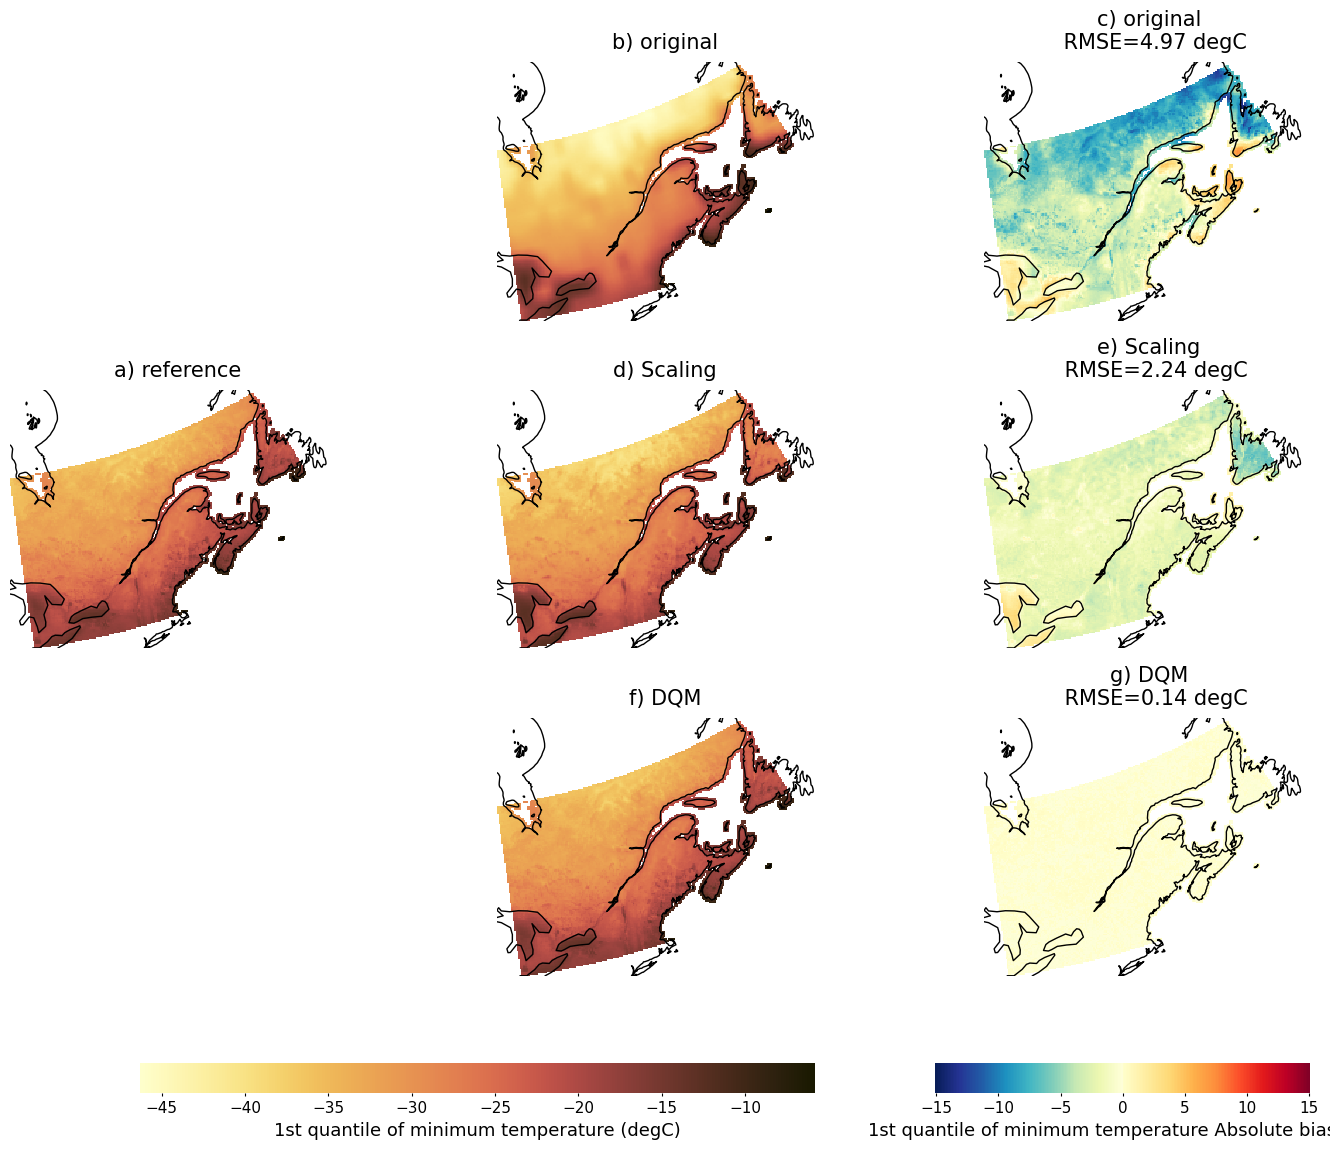

In [78]:
var='q01_tasmin'
prop_ref=xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/ref-prop.zarr.zip")[var]
prop_sim=xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_sim-prop.zarr.zip")[var]
meas_sim_prop=xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_sim-meas.zarr.zip")[var]
prop_scen1=xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_scen-prop.zarr.zip")[var]
meas_scen1_prop=xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_scen-meas.zarr.zip")[var]
prop_scen2=xr.open_zarr(f"{CONFIG['espo']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_scen-prop.zarr.zip")[var]
meas_scen2_prop=xr.open_zarr(f"{CONFIG['espo']}/diagnostics/CaSR/NAM/Atlas/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12/CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM_Atlas_scen-meas.zarr.zip")[var]

maps2(prop_ref, prop_sim, prop_scen1, prop_scen2, meas_sim_prop, meas_scen1_prop, meas_scen2_prop)
plt.savefig(f"{CONFIG['figures']}/q01tasmin_scalingVSDQM.pdf",bbox_inches='tight')


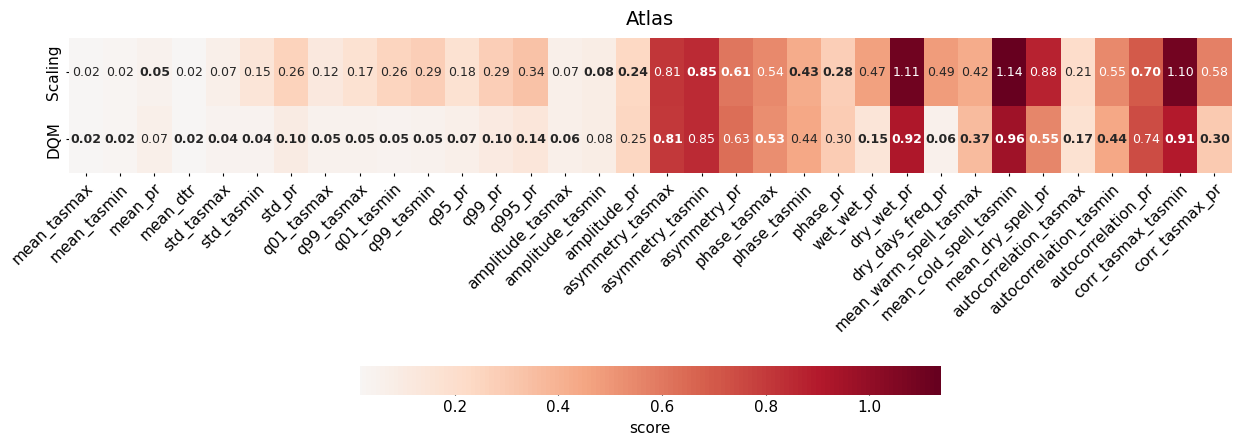

In [89]:
# gab first version of heatmap


ordered_properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr", 'std_tasmax', 'std_tasmin', 'std_pr',
 "q01_tasmax","q99_tasmax","q01_tasmin","q99_tasmin","q95_pr","q99_pr","q995_pr",
 'amplitude_tasmax', 'amplitude_tasmin','amplitude_pr', 
 'asymmetry_tasmax', 'asymmetry_tasmin', 'asymmetry_pr',
'phase_tasmax', 'phase_tasmin', 'phase_pr',
          "wet_wet_pr","dry_wet_pr",'dry_days_freq_pr',           
 "mean_warm_spell_tasmax",'mean_cold_spell_tasmin','mean_dry_spell_pr',
                     'autocorrelation_tasmax','autocorrelation_tasmin', 'autocorrelation_pr',
                   "corr_tasmax_tasmin","corr_tasmax_pr",
                   ]

prop_ref= xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/ref-prop.zarr.zip", decode_timedelta=False)
prop_ref_std=prop_ref.std() # spatial std

all_sims=[]
all_mets=[]

# # regridded
# sims=[]
# adj_dict=cat_sim.search(source='CRCM5-SN',variable='tasmax', experiment='ssp370', processing_level='raw').to_dataset_dict(xarray_open_kwargs={'engine':'h5netcdf'})
# ids=[k.replace('.NAM-12.raw.D','') for k in adj_dict.keys()]
# for sim_id in ids:
#     meas_adj= xr.open_zarr(f"{CONFIG['scaling']}/diagnostics/CaSR/NAM/Atlas/{sim_id}/{sim_id}_NAM_Atlas_sim-meas.zarr.zip", decode_timedelta=False).drop_vars('crs',errors='ignore')
#     meas_adj_mean= abs(meas_adj).mean() # spatial mean
#     meas_adj_mean_std=meas_adj_mean/prop_ref_std
#     sims.append(meas_adj_mean_std.expand_dims(realization=[sim_id]))
#     all_sims.append(meas_adj_mean_std.expand_dims(realization=[f"regridded_{sim_id}"]))
# ds_sims=xr.concat(sims, dim='realization').mean('realization')
# all_mets.append(ds_sims.expand_dims(realization=['regridded only']))

#adjusted
for m in ['scaling','espo']:
    sims=[]
    for sim_id in ids:
        meas_adj= xr.open_zarr(f"{CONFIG[m]}/diagnostics/CaSR/NAM/Atlas/{sim_id}/{sim_id}_NAM_Atlas_scen-meas.zarr.zip", decode_timedelta=False)
        meas_adj_mean= abs(meas_adj).mean() # spatial mean
        meas_adj_mean_std=meas_adj_mean/prop_ref_std
        sims.append(meas_adj_mean_std.expand_dims(realization=[sim_id]))
        all_sims.append(meas_adj_mean_std.expand_dims(realization=[f"{m}_{sim_id}"]))
    ds_sims=xr.concat(sims, dim='realization').mean('realization')
    all_mets.append(ds_sims.expand_dims(realization=[m.replace('scaling','Scaling').replace('espo','DQM')]))


ds_all=xr.concat(all_sims, dim='realization').to_array(dim='properties').T
ds_all=ds_all.sel(properties=ordered_properties)
# ax=fg.heatmap(ds_all,plot_kw={'annot':True, }, fig_kw={'figsize':(15,5)},divergent=0, cmap='RdBu_r')
# ax.set_title('Atlas')

    
ds_mets=xr.concat(all_mets, dim='realization')   
# put props in dims, instead of var
ds_mets=ds_mets.to_array(dim='properties').T

ds_mets=ds_mets.sel(properties=ordered_properties)

ds_mets.attrs['long_name']='score'
ax=fg.heatmap(ds_mets,plot_kw={'annot':True,'fmt':".2f",'annot_kws':{"size": 9},'cbar_kws':{"orientation": "horizontal","pad": 0.5,"shrink": 0.5 }},
              fig_kw={'figsize':(15,5)},divergent=0, cmap='RdBu_r')
ax.set_title('Atlas')
ax.set_ylabel('')
ax.set_xlabel('')

texts = ax.texts


#add match on best
for i in range(len(ds_mets.properties)):
    diff=ds_mets.isel(properties=i, realization=0).values- ds_mets.isel(properties=i, realization=1).values
    #print(diff)
    if diff <0:
        texts[i].set_fontweight('bold')
        #ax.add_patch(Rectangle((i, 0), 1, 1, fill=False, edgecolor='black', lw=2))
    else:
        #ax.add_patch(Rectangle((i, 1), 1, 1, fill=False, edgecolor='black', lw=2))
        texts[len(ds_mets.properties)+i].set_fontweight('bold')

plt.savefig(f"{CONFIG['figures']}/score_ScalingvsDQM.pdf",bbox_inches='tight')




# DQM-tasmin vs DQM-dtr

## create DQM-dtr

DQM-dtr was created by running post-workflow-analysis/create-DQM-dtr.py

In [107]:
patts = [
    "/staging/{type}/{processing_level}/{bias_adjust_project}_{version}_{bias_adjust_reference}/{mip_era}/{activity}/{domain}/{institution}/{source}/{experiment}/{member}/{frequency}/{variable}/{?:_}_{DATES}.zarr.zip",
    "/staging/{type}/{processing_level}/{bias_adjust_project}_{version}_{bias_adjust_reference}/{mip_era}/{activity}/{domain}/{institution}/{source}/{driving_model}/{driving_member}/{experiment}/{member}/{frequency}/{variable}/{?:_}_{DATES}.zarr.zip"
]
df = xs.catutils.parse_directory(directories=[CONFIG['dqm-dtr']],
                                 patterns=patts,
                                 )

display(df)

cat.update(df)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'id.domain.processing_level.xrfreq'


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espo

/project/ctb-frigon/julavoie/ESPOv2/staging/simulation/biasadjusted/ESPO_v20_CaSR/CMIP6/ScenarioMIP/NAM/NOAA-GFDL/GFDL-ESM4/ssp370/r1i1p1f1/day/tasmax/tasmax_day_ESPO6_v20_CaSR+CMIP6_ScenarioMIP_NOAA-GFDL_GFDL-ESM4_ssp370_r1i1p1f1_global_NAM_1951-2100.zarr.zip
/project/ctb-frigon/julavoie/ARCHES/dqm-dtr/staging/simulation/biasadjusted/DQM-dtr_v20_CaSR/CMIP6/ScenarioMIP/NAM/NOAA-GFDL/GFDL-ESM4/ssp370/r1i1p1f1/day/tasmax/tasmax_day_DQM-dtr6_v20_CaSR+CMIP6_ScenarioMIP_NOAA-GFDL_GFDL-ESM4_ssp370_r1i1p1f1_global_NAM_1951-2100.zarr.zip


## temperature inversion

In [ ]:
# swaps=[]
# totals=[]
# for sim_id, ds in cat.search(bias_adjust_project='ESPO', experiment='ssp370').to_dataset_dict().items():
#         sim_id=sim_id.replace('.NAM.biasadjusted.D','').replace('ESPO_CaSR_','ESPO6_v20_CaSR+')
#         if 'ScenarioMIP' in sim_id:
#             sim_id=sim_id.replace('_NAM','_global_NAM')
#         else:
#             sim_id=sim_id.replace('_NAM','_NAM-12_NAM')
#         # original dtr to find mask of inversions.
#         dtrpreswap=xr.open_zarr(f"{CONFIG['espo']}/preswap/dtrpreswap_day_{sim_id}.zarr.zip")
#         swap= (dtrpreswap<0).resample(time='QS-DEC').sum()
#         swap=swap.sel(time=slice('1951-01','2099-11'))
#         swap=xs.utils.unstack_dates(swap).expand_dims(realization=[sim_id])
#         swap=swap.convert_calendar('noleap', align_on='year')
#         total= dtrpreswap.resample(time='QS-DEC').count()
#         total=total.sel(time=slice('1951-01','2099-11'))
#         total=total.convert_calendar('noleap', align_on='year')
#         total=xs.utils.unstack_dates(total).expand_dims(realization=[sim_id])
    
#         swaps.append(swap)
#         totals.append(total)
swaps=[ds.convert_calendar('noleap', align_on='year') for ds in swaps]
totals=[ds.convert_calendar('noleap', align_on='year') for ds in totals]

ds_swap=xr.concat(swaps, dim='realization')
ds_total=xr.concat(totals, dim='realization')



fig, axs = plt.subplots(2,4, figsize=(15,8), subplot_kw={'projection':map_proj})
for i,season in enumerate(['DJF', 'MAM','JJA','SON']):
    for j, period in enumerate([['1991','2020'],['2071','2100']]):
        curswap=ds_swap.sel(time=slice(*period), season=season).sum(dim=['time','realization'])
        curtotal=ds_total.sel(time=slice(*period), season=season).sum(dim=['time','realization'])
        frac=curswap/curtotal
        frac.dtr.attrs['long_name']='fraction of inversions'
        del frac.dtr.attrs['units']
        fg.gridmap(frac, features=fe, ax=axs[j,i],levels = [0,0.005,0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05])
        axs[j,i].set_title(f"{season} {period} \n max= {round(float(frac.dtr.max().values),2)}")
plt.savefig(f"{CONFIG['figures']}/inversionsmap_season.png",bbox_inches='tight')



/tmp/ipykernel_204226/1423562530.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
/tmp/ipykernel_204226/1423562530.py:26: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not fou

In [23]:
print(list(cat.df.source.unique()))e

['CRCM5-SN', 'NorESM2-LM', 'NorESM2-MM', 'MRI-ESM2-0', 'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'EC-Earth3', 'EC-Earth3-Veg', 'CanESM5-1', 'CanESM5', 'FGOALS-g3', 'BCC-CSM2-MR', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'TaiESM1', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CMCC-ESM2', 'ACCESS-ESM1-5', 'UKESM1-0-LL', 'ACCESS-CM2', 'MPI-ESM1-2-LR', 'GFDL-ESM4']


## variance distortion

/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


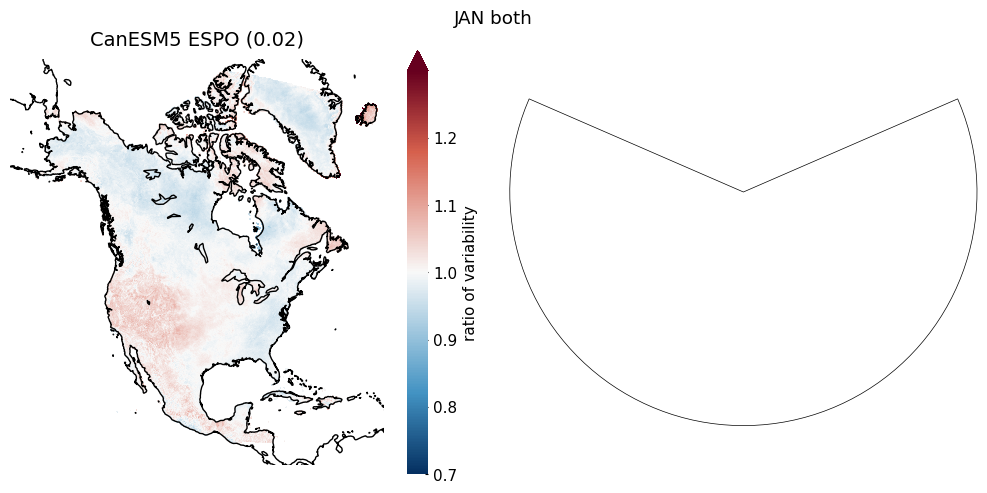

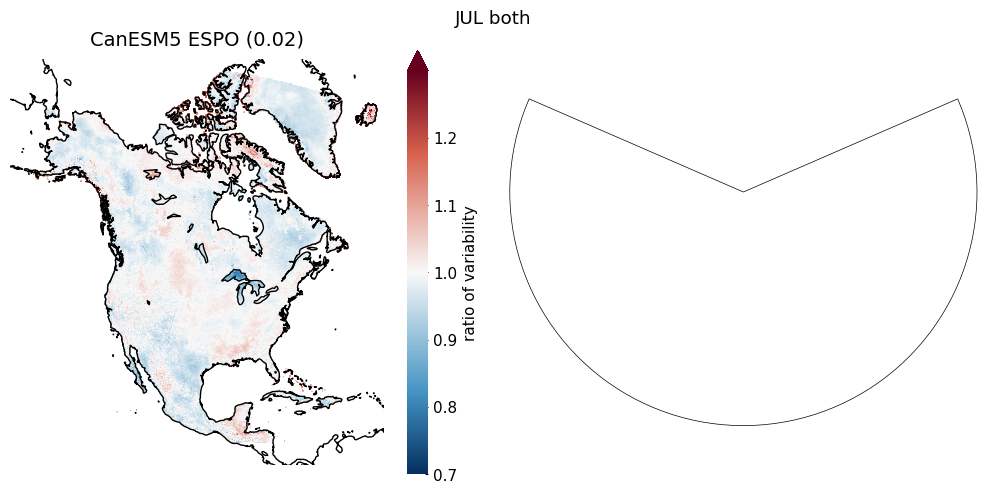

In [9]:
# both
var='tasmin'
fig, axs= plt.subplots(1,2,subplot_kw={'projection': map_proj}, figsize=(10,5))
fig.suptitle('JAN both')
fig2, axs2= plt.subplots(1,2,subplot_kw={'projection': map_proj}, figsize=(10,5))
fig2.suptitle('JUL both')

ds_ref=xr.open_zarr(f"{CONFIG['scaling']}/reference/NAM_CaSR_fullregion.zarr.zip", decode_timedelta=False)
ds_ref=ds_ref.sel(time=slice('1991','2020'))

ds_refJAN=ds_ref.sel(time=(ds_ref.time.dt.month == 1))
ds_refJUL=ds_ref.sel(time=(ds_ref.time.dt.month == 7))

std_refJAN= ds_refJAN.std('time').tasmin
std_refJUL= ds_refJUL.std('time').tasmin
Path(f"{CONFIG['arches']}/ratiovar").mkdir(parents=True, exist_ok=True)

for i,dm in enumerate(['CanESM5']):
    for j,m in enumerate(['ESPO']):#,'DQM-dtr']):
        ds=cat.search(driving_model=dm, source='CRCM5-SN', experiment='ssp370', bias_adjust_project=m, variable=var).to_dataset()
        ds=ds.sel(time=slice('1991','2020'))
        dsJAN=ds.sel(time=(ds.time.dt.month == 1))
        dsJUL=ds.sel(time=(ds.time.dt.month == 7))

        stdJAN= dsJAN.std('time').tasmin
        stdJUL= dsJUL.std('time').tasmin


        ratioJAN=stdJAN/std_refJAN
        ratioJAN.attrs['long_name']= 'adj std / CaSR std'

        path= f"{CONFIG['arches']}/ratiovar/ratiovar_both_JAN_{dm}_{m}.zarr"
        
        if not  Path(path).exists():
            xs.save_to_zarr(ratioJAN.to_dataset(name=var), path, rechunk={'rlat':-1, 'rlon':-1})
        else:
            ratioJAN = xr.open_zarr(path)[var]
            ratioJAN.attrs['long_name']= 'ratio of variability'
            del ratioJAN.attrs['units']
            fg.gridmap(ratioJAN, divergent=1, ax=axs[j], plot_kw={'vmin':0.75, 'vmax':1.25},features=fe)
            axs[j].set_title(f"{m.replace('ESPO','DQM-tasmin')} ({round(float(abs(ratioJAN-1).where(~np.isinf(ratioJAN)).mean().values),2)})")

        ratioJUL=stdJUL/std_refJUL

        path= f"{CONFIG['tmppath']}/ratiovar_both_JUL_{dm}_{m}.zarr"
        if not  Path(path).exists():
            xs.save_to_zarr(ratioJUL.to_dataset(name=var), path, rechunk={'rlat':-1, 'rlon':-1})
        else:
            ratioJUL = xr.open_zarr(path)[var]
            ratioJUL.attrs['long_name']= 'ratio of variability'
            del ratioJUL.attrs['units']
            fg.gridmap(ratioJUL, divergent=1, ax=axs2[j], plot_kw={'vmin':0.75, 'vmax':1.25},features=fe)
            axs2[j].set_title(f"{m.replace('ESPO','DQM-tasmin')}} ({round(float(abs(ratioJUL-1).where(~np.isinf(ratioJUL)).mean().values),2)})")
fig.tight_layout()
fig2.tight_layout()
#fig.savefig(f"{CONFIG['figures']}/ratiovar_CRCM5_CanESM5_both_JAN.png",bbox_inches='tight')
#fig2.savefig(f"{CONFIG['figures']}/ratiovar_CRCM5_CanESM5_both_JUL.png",bbox_inches='tight')


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


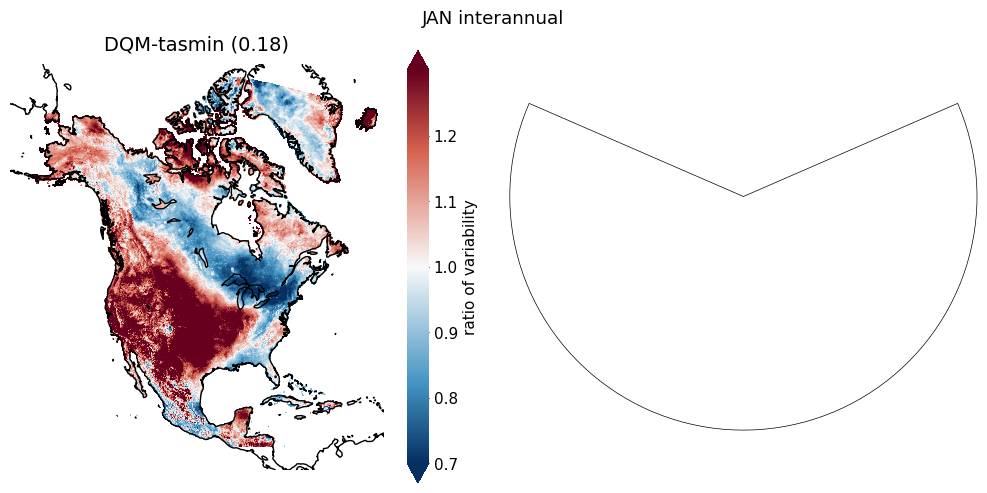

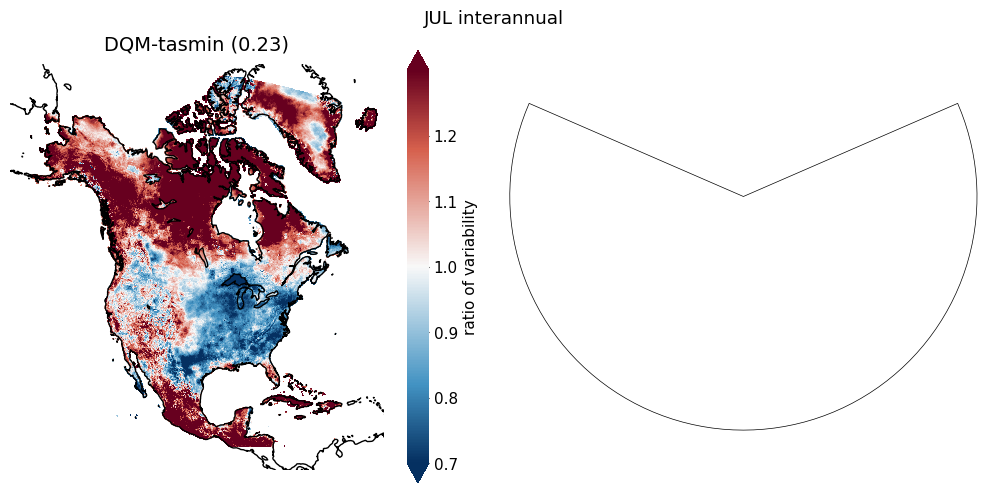

In [14]:



# interannual
var='tasmin'
fig, axs= plt.subplots(1,2,subplot_kw={'projection': map_proj}, figsize=(10,5))
fig.suptitle('JAN interannual')
fig2, axs2= plt.subplots(1,2,subplot_kw={'projection': map_proj}, figsize=(10,5))
fig2.suptitle('JUL interannual')

ds_ref=xr.open_zarr(f"{CONFIG['scaling']}/reference/NAM_CaSR_fullregion.zarr.zip", decode_timedelta=False)
ds_ref=ds_ref.sel(time=slice('1991','2020'))
if var =='pr':
    with xr.set_options(keep_attrs=True):
        ds_ref['pr']=xc.core.units.convert_units_to(ds_ref['pr'], 'mm/day', context='hydro')

ds_ref=ds_ref.resample(time='MS').mean('time')
ds_ref=xs.utils.unstack_dates(ds_ref)
std_ref=ds_ref.std('time').tasmin


for i,dm in enumerate(['CanESM5']):
    for j,m in enumerate(['ESPO']):#,'DQM-dtr']):
        ds=cat.search(driving_model=dm, source='CRCM5-SN', experiment='ssp370', bias_adjust_project=m, variable=var).to_dataset()
        ds=ds.sel(time=slice('1991','2020'))
        if var =='pr':
            with xr.set_options(keep_attrs=True):
                ds['pr']=xc.core.units.convert_units_to(ds['pr'], 'mm/day', context='hydro')
        ds=ds.resample(time='MS').mean('time')
        ds=xs.utils.unstack_dates(ds)
        std=ds.std('time').tasmin
        
        ratio=std/std_ref
        ratioJAN.attrs['long_name']= 'ratio of variability'

        path= f"{CONFIG['tmppath']}/ratiovar_interannual_{dm}_{m}.zarr"
        if not  Path(path).exists():
            xs.save_to_zarr(ratio.to_dataset(name=var), path, rechunk={'rlat':-1, 'rlon':-1})
        else:
            ratio = xr.open_zarr(path)[var]
            ratio.attrs['long_name']= 'ratio of variability'
            del ratio.attrs['units']
            fg.gridmap(ratio.sel(month='JAN'), divergent=1, ax=axs[j], plot_kw={'vmin':0.75, 'vmax':1.25},features=fe)
            axs[j].set_title(f"{m.replace('ESPO','DQM-tasmin')} ({round(float(abs(ratio.sel(month='JAN')-1).where(~np.isinf(ratio.sel(month='JAN'))).mean().values),2)})")
            fg.gridmap(ratio.sel(month='JUL'), divergent=1, ax=axs2[j], plot_kw={'vmin':0.75, 'vmax':1.25},features=fe)
            axs2[j].set_title(f"{m.replace('ESPO','DQM-tasmin')} ({round(float(abs(ratio.sel(month='JUL')-1).where(~np.isinf(ratio.sel(month='JUL'))).mean().values),2)})")
fig.tight_layout()
fig2.tight_layout()
# fig.savefig(f"{CONFIG['figures']}/ratiovar_CRCM5_CanESM5_interannual_JAN.png",bbox_inches='tight')
# fig2.savefig(f"{CONFIG['figures']}/ratiovar_CRCM5_CanESM5_interannual_JUL.png",bbox_inches='tight')


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:678: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


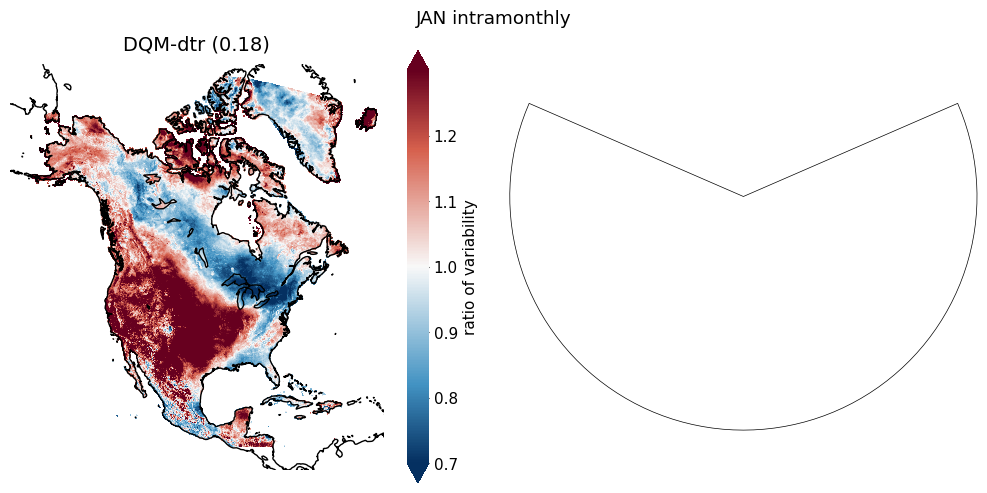

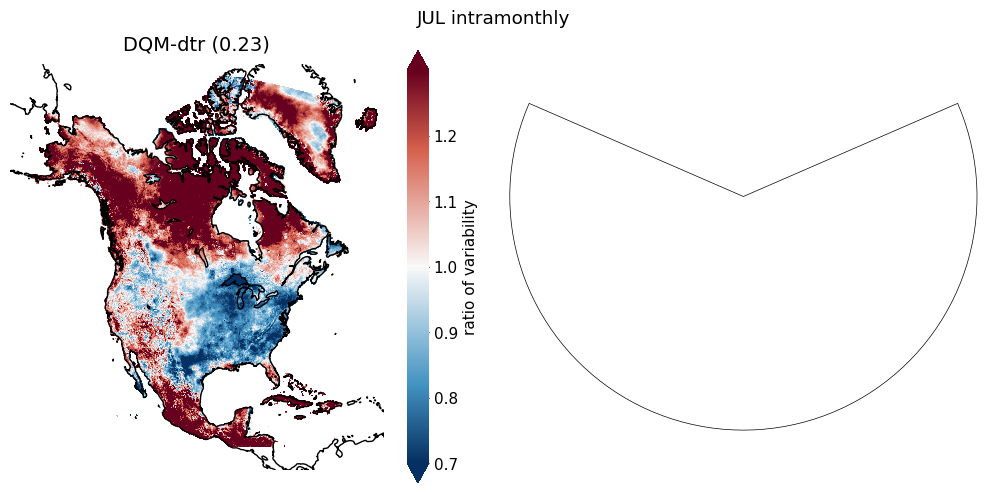

In [16]:
# intramensuel
var='tasmin'
fig, axs= plt.subplots(1,2,subplot_kw={'projection': map_proj}, figsize=(10,5))
fig.suptitle('JAN intramonthly')
fig2, axs2= plt.subplots(1,2,subplot_kw={'projection': map_proj}, figsize=(10,5))
fig2.suptitle('JUL intramonthly')

ds_ref=xr.open_zarr(f"{CONFIG['scaling']}/reference/NAM_CaSR_fullregion.zarr.zip", decode_timedelta=False)
ds_ref=ds_ref.sel(time=slice('1991','2020'))

ds_ref=ds_ref.resample(time='MS').var('time')
ds_ref=xs.utils.unstack_dates(ds_ref)
std_ref=np.sqrt(ds_ref.mean('time').tasmin)

for i,dm in enumerate(['CanESM5']):
    for j,m in enumerate(['ESPO']):#,'DQM-dtr']):
        ds=cat.search(driving_model=dm, source='CRCM5-SN', experiment='ssp370', bias_adjust_project=m, variable=var).to_dataset()
        ds=ds.sel(time=slice('1991','2020'))

        ds=ds.resample(time='MS').var('time')
        ds=xs.utils.unstack_dates(ds)
        std=np.sqrt(ds.mean('time').tasmin)
        
        ratio=std/std_ref
        ratio.attrs['long_name']= 'adj std / CaSR std'

        path= f"{CONFIG['tmppath']}/ratiovar_interannual_{dm}_{m}.zarr"
        if not  Path(path).exists():
            xs.save_to_zarr(ratio.to_dataset(name=var), path, rechunk={'rlat':-1, 'rlon':-1})
        else:
            ratio = xr.open_zarr(path)[var]
            ratio.attrs['long_name']= 'ratio of variability'
            del ratio.attrs['units']
            fg.gridmap(ratio.sel(month='JAN'), divergent=1, ax=axs[j], plot_kw={'vmin':0.75, 'vmax':1.25},features=fe)
            axs[j].set_title(f"{m.replace('ESPO','DQM-dtr')} ({round(float(abs(ratio.sel(month='JAN')-1).where(~np.isinf(ratio.sel(month='JAN'))).mean().values),2)})")
            fg.gridmap(ratio.sel(month='JUL'), divergent=1, ax=axs2[j], plot_kw={'vmin':0.75, 'vmax':1.25},features=fe)
            axs2[j].set_title(f"{m.replace('ESPO','DQM-dtr')} ({round(float(abs(ratio.sel(month='JUL')-1).where(~np.isinf(ratio.sel(month='JUL'))).mean().values),2)})")
fig.tight_layout()
fig2.tight_layout()
#fig.savefig(f"{CONFIG['figures']}/ratiovar_CRCM5_CanESM5_intramontly2_JAN.png",bbox_inches='tight')
#fig2.savefig(f"{CONFIG['figures']}/ratiovar_CRCM5_CanESM5_intramontly2_JUL.png",bbox_inches='tight')
